In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [28]:
df = pd.read_csv("data/train.csv")  # csv読み込み
df.head()                           # 最初の５行だけ表示

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
df.shape    # データフレームのサイズ；(行数, 列数)

(891, 12)

In [4]:
df.describe()         # 統計値の算出           

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [25]:
# 名前、年齢、生存を抽出
df1 = df[["Name", "Age", "Survived"]].head()       # 任意の列を抽出

In [24]:
# 生存者だけを抽出
df1[df["Survived"] == 1].head()      # 条件で絞る

,Name,Age,Survived
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1
2,"Heikkinen, Miss. Laina",26.0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0,1
9,"Nasser, Mrs. Nicholas (Adele Achem)",14.0,1


In [ ]:
# 社会的地位が高く, 生存した男性
df2 = df[(df["Pclass"] == 1) & (df["Survived"] == 1) & (df["Sex"] == "male")]
df2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
55,56,1,1,"Woolner, Mr. Hugh",male,NaN,0,0,19947,35.5000,C52,S
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,0,1,PC 17759,63.3583,D10 D12,C
187,188,1,1,"Romaine, Mr. Charles Hallace (""Mr C Rolmane"")",male,45.0,0,0,111428,26.5500,NaN,S
209,210,1,1,"Blank, Mr. Henry",male,40.0,0,0,112277,31.0000,A31,C


In [ ]:
# 列の削除
df2.drop(["Parch", "SibSp", "Ticket", "Embarked"], axis=1).head()   # 行方向;axis=0, 列方向;axis=1

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Cabin
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,35.5000,A6
55,56,1,1,"Woolner, Mr. Hugh",male,NaN,35.5000,C52
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,63.3583,D10 D12
187,188,1,1,"Romaine, Mr. Charles Hallace (""Mr C Rolmane"")",male,45.0,26.5500,NaN
209,210,1,1,"Blank, Mr. Henry",male,40.0,31.0000,A31


In [ ]:
# 生存者と非生存者の人数を計算
survived_count = df[df["Survived"] == 1]["PassengerId"].count()         # ["PassengerId"]を付けないと各列でも同様に計算されてしまう
non_survived_count = df[df["Survived"] == 0]["PassengerId"].count()

# 結果
print(f"生存者 {survived_count}人")
print(f"死亡者 {non_survived_count}人")

生存者 342人
死亡者 549人


In [58]:
# 男女毎の平均年齢
avg_age_male = df[df["Sex"] == "male"]["Age"].mean()    # 男性の年齢で平均
male = round(avg_age_male, 1)                           # 少数第１位まで表示

avg_age_female = df[df["Sex"] == "female"]["Age"].mean()
female = round(avg_age_female, 1) 

print(f"男性 {male}歳")
print(f"女性 {female}歳")

男性 30.7歳
女性 27.9歳


In [67]:
# 男女のチケット代の中央値
male_median_fare = df[df["Sex"] == "male"]["Fare"].median()
male = round(male_median_fare, 1)

female_median_fare = df[df["Sex"] == "female"]["Fare"].median()
female = round(female_median_fare, 1)

print(f"男性 {male}₤")
print(f"女性 {female}₤")

男性 10.5₤
女性 23.0₤


In [71]:
# 現在の為替に変換
today_male = male * 150 * 218
today_male = round(today_male)

today_female = female * 150 * 218
today_female = round(today_female)

print(f"男性 {today_male:,}円")
print(f"女性 {today_female:,}円")

男性 343,350円
女性 752,100円


In [ ]:
# 男性の客室クラス毎の料金の中央値
male_median_fare = df[(df["Sex"] == "male")].groupby("Pclass")["Fare"].median()
male_median_fare = round(male_median_fare)

print("<男性>")
for pclass, fare in male_median_fare.items():
    print(f"{pclass}等: {fare}₤")
print("")

# 女性の客室クラス毎の料金の中央値
female_median_fare = df[(df["Sex"] == "female")].groupby("Pclass")["Fare"].median()
female_median_fare = round(female_median_fare)

print("<女性>")
for pclass, fare in female_median_fare.items():
    print(f"{pclass}等: {fare}₤")

<男性>
1等: 41.0₤
2等: 13.0₤
3等: 8.0₤

<女性>
1等: 83.0₤
2等: 22.0₤
3等: 12.0₤


In [92]:
# 現在の為替に変換
today_male = (male_median_fare * 150 * 218).round().astype(int)
today_female = (female_median_fare * 150 * 218).round().astype(int)

print("<男性>")
for pclass, fare in today_male.items():
    print(f"{pclass}等：{fare:,}円")
print("")

print("<女性>")
for pclass, fare in today_female.items():
    print(f"{pclass}等：{fare:,}円")


<男性>
1等：1,340,700円
2等：425,100円
3等：261,600円

<女性>
1等：2,714,100円
2等：719,400円
3等：392,400円


In [95]:
# 年齢の最大値・最小値
max_age = df["Age"].max()
min_age = df["Age"].min()

print(f"最高齢: {max_age}")
print(f"最年少: {min_age}")

最高齢: 80.0
最年少: 0.42


In [108]:
# 女性の年齢と料金の相関係数
female_corr = df[df["Sex"] == "female"]["Age"].corr(
    df[df["Sex"] == "female"]["Fare"]
)

print(female_corr)

0.17146778985057115


In [ ]:
# .locを使って書くと...
female = df.loc[df["Sex"] == "female"]              # 女性を抽出
female_corr = female["Age"].corr(female["Fare"])    # 年齢と料金の相関係数

print(female_corr)

0.17146778985057115


In [111]:
# 女性の年齢と料金の相関係数
female = df[df["Sex"] == "female"]                  # 女性を抽出
correlation = female[['Age', 'Fare']].corr()        # 年齢と料金の相関係数

print(correlation)

           Age      Fare
Age   1.000000  0.171468
Fare  0.171468  1.000000


In [ ]:
# 年齢で昇順にソート(降順；ascending=False)
df.sort_values(by=["Age"], ascending=True).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S


In [114]:
# 性別毎に年齢を平均
df.groupby("Sex")["Age"].mean().round()

Sex
female    28.0
male      31.0
Name: Age, dtype: float64

In [116]:
# 列名の変更
df.rename(columns={"Pclass": "客室クラス", "Sex": "性別"}, inplace=False).head()   # inplace;元データを上書きするか

,PassengerId,Survived,客室クラス,Name,性別,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# 任意の行と列を抽出
df.loc[0:2, ["Name", "Age"]]    # df.loc[行, [列]]

,Name,Age
0,"Braund, Mr. Owen Harris",22.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0
2,"Heikkinen, Miss. Laina",26.0


In [122]:
# 条件で絞る！
df.query("Sex == 'female' and Survived == 1").head()      # 列名は'で囲う

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [123]:
# 条件で絞る！(復習)
df[(df["Sex"] == "female") & (df["Survived"] == 1)].head()      # 条件で絞る

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [126]:
# 列名を数値に変換(カテゴリ変数化)
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
df["Sex"] = le_sex.fit_transform(df["Sex"])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


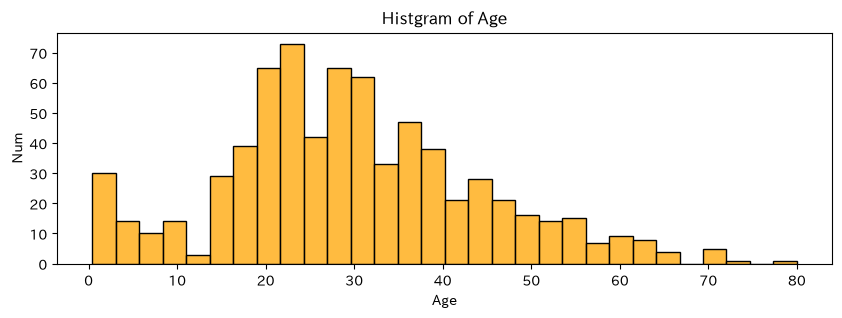

In [130]:
# 年齢と人数のヒストグラム
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns

plt.figure(figsize=(10, 3))
sns.histplot(df["Age"].dropna(), bins=30, kde=False, color="orange")    # dropna();欠損値の削除, bins;区分数(本数), kde;分布曲線

plt.title("Histgram of Age")
plt.xlabel("Age")
plt.ylabel("Num")

plt.show()

In [144]:
# 性別毎の人数をカウント
sex_counts = df["Sex"].value_counts()
print(sex_counts)

Sex
1    577
0    314
Name: count, dtype: int64


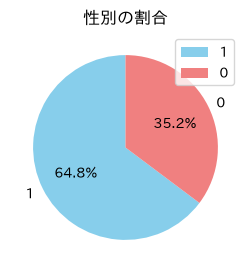

In [ ]:
# 円グラフ作成
plt.figure(figsize=(10, 3))
plt.pie(
    sex_counts, 
    labels=sex_counts.index,                # ラベル
    startangle=90,                          # 90度回転
    autopct='%1.1f%%',                      # 少数第一位までの割合を表示
    colors=["skyblue", "lightcoral"]
)
plt.title("性別の割合")
plt.legend(loc="upper right")               # 凡例を右上に表示
plt.show()

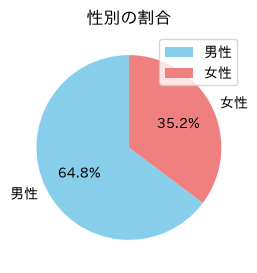

In [159]:
# 円グラフ作成
plt.figure(figsize=(10, 3))
plt.pie(
    sex_counts, 
    labels=["男性", "女性"],                # ラベルを直接指定
    startangle=90,                         # 90度回転
    autopct='%1.1f%%',                      # 少数第一位までの割合を表示
    colors=["skyblue", "lightcoral"]
)
plt.title("性別の割合")
plt.legend(loc="upper right")
plt.show()

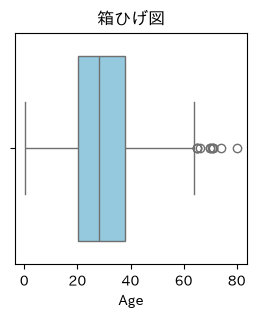

In [156]:
# 箱ひげ図
plt.figure(figsize=(3, 3))
sns.boxplot(x='Age', data=df, orient='h', color='skyblue')  # df["Age"]から箱ひげ図を作成, data;データフレームを指定, orient;表示向き
plt.title('箱ひげ図')
plt.show()

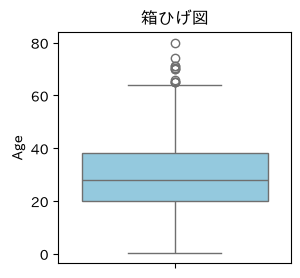

In [157]:
# 箱ひげ図
plt.figure(figsize=(3, 3))
sns.boxplot(y='Age', data=df, orient='v', color='skyblue')  # df["Age"]から箱ひげ図を作成, data;データフレームを指定, orient;表示向き
plt.title('箱ひげ図')
plt.show()

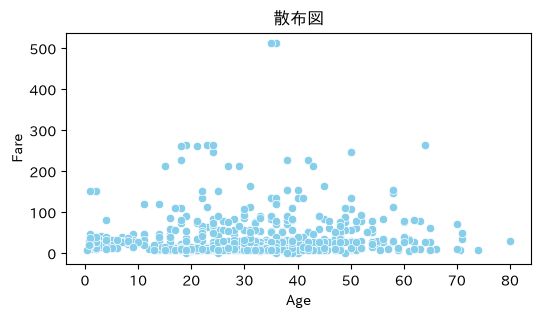

In [171]:
# 散布図
plt.figure(figsize=(6, 3))
sns.scatterplot(x="Age", y="Fare", data=df, color="skyblue")
plt.title("散布図")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

In [ ]:
# 最高料金の乗客は生存したのか
df[df["Fare"] == df["Fare"].max()].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",0,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",1,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",1,35.0,0,0,PC 17755,512.3292,B101,C


In [ ]:
# 料金が高い順にソート
df.sort_values("Fare", ascending=False).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",1,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
258,259,1,1,"Ward, Miss. Anna",0,35.0,0,0,PC 17755,512.3292,NaN,C
737,738,1,1,"Lesurer, Mr. Gustave J",1,35.0,0,0,PC 17755,512.3292,B101,C
88,89,1,1,"Fortune, Miss. Mabel Helen",0,23.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",1,64.0,1,4,19950,263.0000,C23 C25 C27,S
